In [51]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [52]:
file_path = "../data/Run200_Wave_0_1.txt"

with open(file_path, "r") as f:
    for i in range(5):
        print(f.readline())

         2890276   357   113    500  14820 14823 14824 14822 14818 14820 14824 14822 14820 14820 14820 14822 14824 14820 14828 14819 14822 14822 14820 14822 14820 14819 14820 14821 14815 14830 14824 14825 14820 14820 14824 14822 14817 14825 14820 14814 14822 14823 14824 14820 14820 14823 14822 14817 14824 14826 14823 14822 14818 14822 14820 14817 14820 14821 14822 14820 14818 14820 14820 14825 14818 14819 14824 14822 14818 14820 14827 14826 14824 14819 14820 14822 14820 14820 14822 14825 14822 14821 14817 14822 14819 14821 14823 14821 14817 14820 14827 14820 14820 14823 14820 14815 14820 14822 14820 14824 14817 14818 14819 14822 14819 14818 14827 14820 14818 14820 14819 14818 14820 14824 14822 14820 14817 14822 14820 14817 14824 14822 14823 14824 14820 14825 14818 14823 14817 14820 14824 14824 14815 14820 14820 14822 14817 14822 14820 14820 14820 14822 14820 14819 14818 14823 14818 14818 14820 14814 14763 14563 14378 14291 14378 14460 14532 14607 14630 14681 14732 14741 14748 14756 147

In [3]:
with open("../data/Run200_Wave_0_1.txt", "r") as f:
    first_line = f.readline()

values = first_line.split()

print("Количество элементов:", len(values))

Количество элементов: 504


In [4]:
data = pd.read_csv(
    "../data/Run200_Wave_0_1.txt",
    sep=r"\s+",
    header=None
)

data.shape

(23479, 504)

In [5]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,14819,14818,14827,14820,14818,14820,14819,14818,14820,14824,14822,14820,14817,14822,14820,14817,14824,14822,14823,14824,14820,14825,14818,14823,14817,14820,14824,14824,14815,14820,14820,14822,14817,14822,14820,14820,14820,14822,14820,14819,14818,14823,14818,14818,14820,14814,14763,14563,14378,14291,14378,14460,14532,14607,14630,14681,14732,14741,14748,14756,14772,14779,14790,14792,14799,14801,14799,14797,14792,14803,14798,14794,14794,14814,14808,14811,14810,14807,14815,14810,14807,14801,14804,14804,14801,14801,14810,14806,14791,14813,14799,14802,14804,14811,14812,14803,14803,14812,14816,14819,14812,14809,14817,14817,14815,14817,14820,14817,14812,14816,14819,14816,14815,14822,14806,14817,14809,14813,14810,14813,14812,14819,14812,14815,14812,14823,14810,14810,14819,14819,14822,14813,14816,14820,14816,14817,14820,14819,14817,14821,14820,14826,14819,14820,14820,14826,14819,14821,14812,14820,14817,14813,14812,14815,14815,14814,14817,14817,14817,14815,14814,14820,14815,14813,14810,14820,14822,14821,14818,14818,14819,14820,14812,14818,14820,14816,14818,14819,14817,14819,14820,14816,14817,14816,14819,14819,14818,14818,14817,14820,14818,14824,14823,14813,14817,14818,14815,14825,14819,14827,14818,14815,14820,14823,14815,14822,14827,14822,14818,14818,14818,14822,14812,14830,14819,14817,14823,14828,14824,14810,14817,14827,14823,14814,14820,14821,14820,14816,14818,14828,14818,14822,14819,14823,14817,14816,14824,14822,14823,14818,14822,14825,14820,14823,14818,1

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 504 entries, 0 to 503
dtypes: int64(504)
memory usage: 90.3 MB


In [7]:
meta = data.iloc[:, :4]

signals = data.iloc[:, 4:]

meta.shape, signals.shape

((23479, 4), (23479, 500))

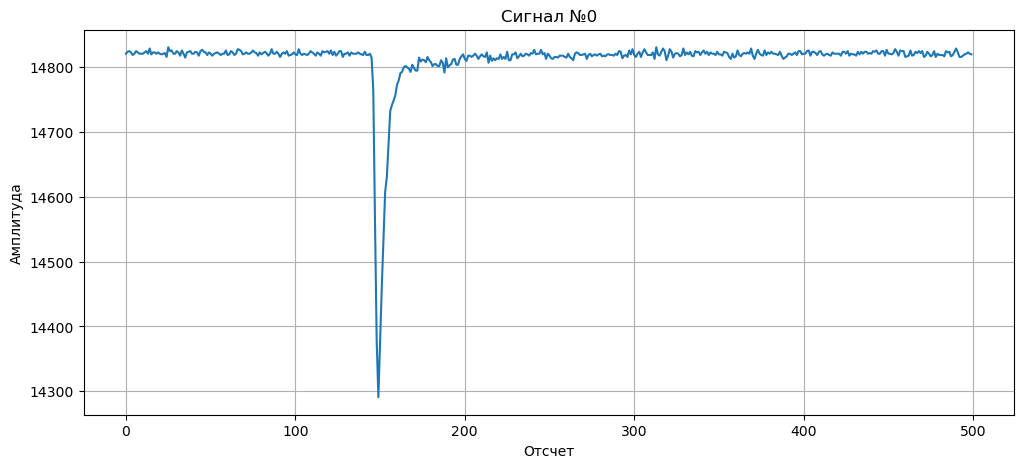

In [8]:
signal_0 = signals.iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(signal_0.values)

plt.xlabel("Отсчет")
plt.ylabel("Амплитуда")
plt.title("Сигнал №0")

plt.grid()
plt.show()

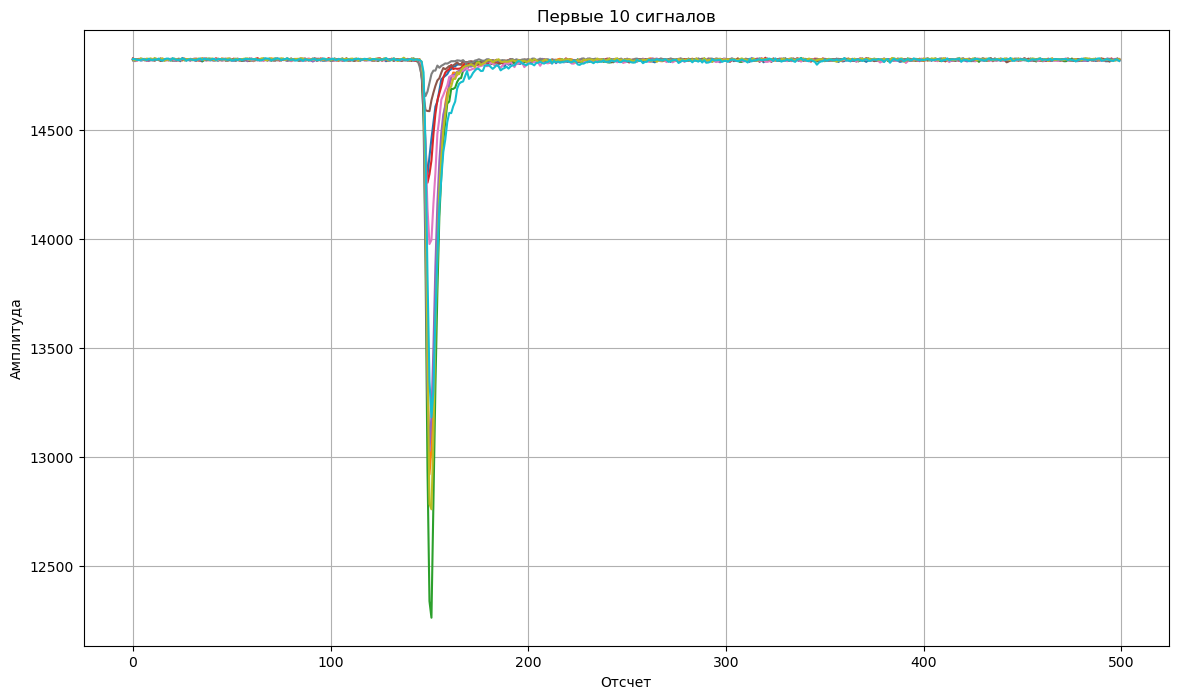

In [9]:
plt.figure(figsize=(14, 8))

for i in range(10):
    plt.plot(signals.iloc[i].values)

plt.xlabel("Отсчет")
plt.ylabel("Амплитуда")
plt.title("Первые 10 сигналов")

plt.grid()
plt.show()

In [10]:
baseline = signals.iloc[:, :100].mean(axis=1)

minimum = signals.min(axis=1)

amplitude = baseline - minimum

amplitude.describe()

count    23479.000000
mean      1835.103314
std       2389.301353
min        104.230000
25%        308.220000
50%        812.720000
75%       2315.270000
max      14824.820000
dtype: float64

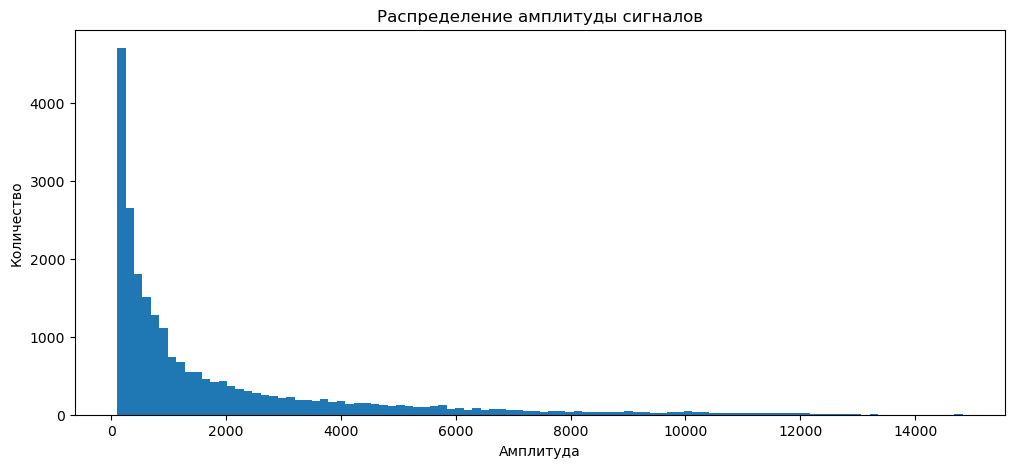

In [11]:
plt.figure(figsize=(12, 5))

plt.hist(amplitude, bins=100)

plt.xlabel("Амплитуда")
plt.ylabel("Количество")
plt.title("Распределение амплитуды сигналов")

plt.show()

In [12]:
features = pd.DataFrame()

features["baseline"] = signals.iloc[:, :100].mean(axis=1)

features["minimum"] = signals.min(axis=1)

features["amplitude"] = (
    features["baseline"] - features["minimum"]
)

features.head()

,baseline,minimum,amplitude
0,14821.13,14291,530.13
1,14822.47,12921,1901.47
2,14821.92,12264,2557.92
3,14822.76,14258,564.76
4,14821.43,13028,1793.43


In [13]:
features["min_position"] = signals.idxmin(axis=1) - 4

features.head()

,baseline,minimum,amplitude,min_position
0,14821.13,14291,530.13,149
1,14822.47,12921,1901.47,150
2,14821.92,12264,2557.92,151
3,14822.76,14258,564.76,149
4,14821.43,13028,1793.43,150


In [14]:
features["min_position"].describe()

count    23479.000000
mean       149.628604
std          2.489996
min        145.000000
25%        149.000000
50%        150.000000
75%        151.000000
max        472.000000
Name: min_position, dtype: float64

In [15]:
pulse = features["baseline"].values.reshape(-1, 1) - signals

features["area"] = pulse.clip(lower=0).sum(axis=1)

features.head()

,baseline,minimum,amplitude,min_position,area
0,14821.13,14291,530.13,149,4983.28
1,14822.47,12921,1901.47,150,12655.80
2,14821.92,12264,2557.92,151,17264.16
3,14822.76,14258,564.76,149,5015.84
4,14821.43,13028,1793.43,150,12013.03


In [16]:
features[["amplitude", "area"]].describe()

,amplitude,area
count,23479.000000,23479.000000
mean,1835.103314,13515.269515
std,2389.301353,16026.866544
min,104.230000,1087.400000
25%,308.220000,2884.815000
50%,812.720000,6628.800000
75%,2315.270000,17619.885000
max,14824.820000,113277.260000


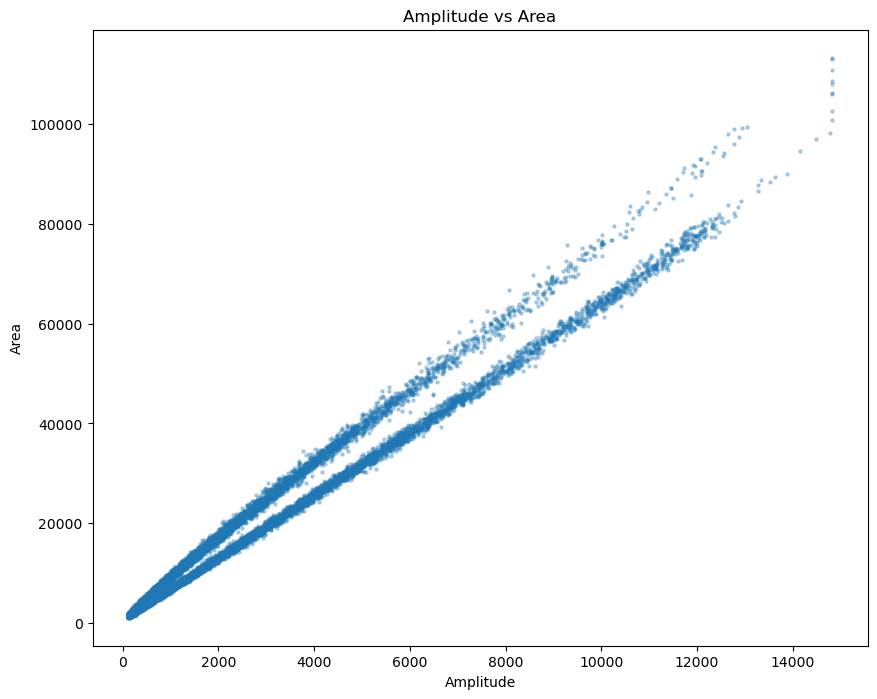

In [17]:
plt.figure(figsize=(10, 8))

plt.scatter(
    features["amplitude"],
    features["area"],
    s=5,
    alpha=0.3
)

plt.xlabel("Amplitude")
plt.ylabel("Area")
plt.title("Amplitude vs Area")

plt.show()

In [18]:
features["shape_ratio"] = (
    features["area"] /
    features["amplitude"]
)

features["shape_ratio"].describe()

count    23479.000000
mean         8.672729
std          1.950465
min          5.219705
25%          6.894774
50%          8.430781
75%          9.892035
max         19.600796
Name: shape_ratio, dtype: float64

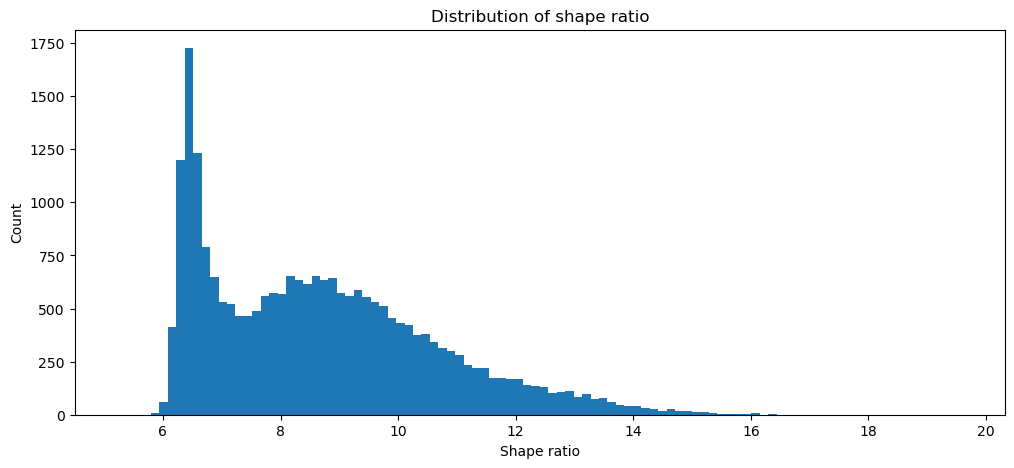

In [19]:
plt.figure(figsize=(12, 5))

plt.hist(
    features["shape_ratio"],
    bins=100
)

plt.xlabel("Shape ratio")
plt.ylabel("Count")
plt.title("Distribution of shape ratio")

plt.show()

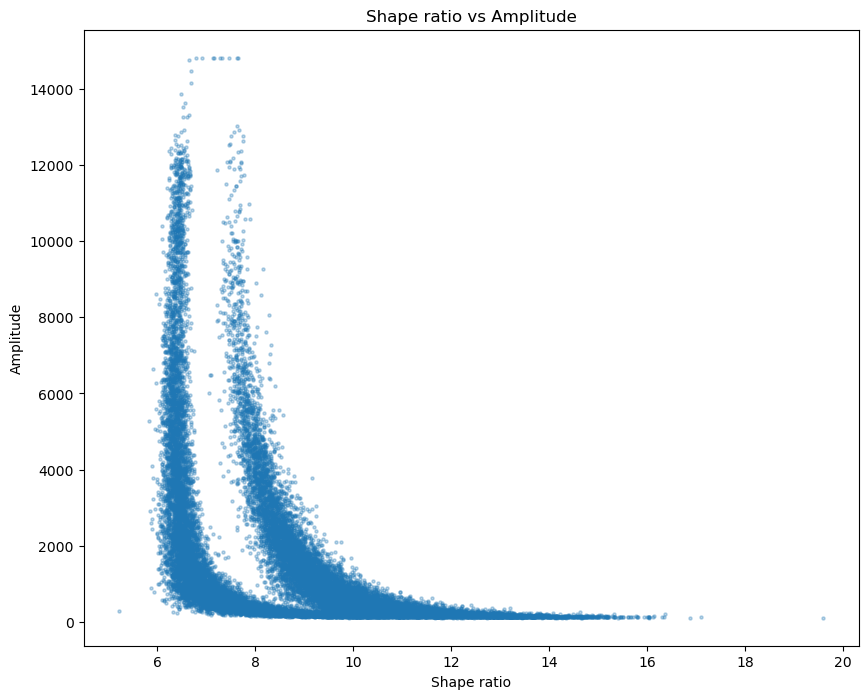

In [80]:
plt.figure(figsize=(10, 8))

plt.scatter(
    features["shape_ratio"],
    features["amplitude"],
    s=5,
    alpha=0.3
)

plt.xlabel("Shape ratio")
plt.ylabel("Amplitude")
plt.title("Shape ratio vs Amplitude")

plt.show()

Датасет содержит 23479 сигналов, каждый из которых представлен 500 отсчетами.
Пропусков в данных не обнаружено.
Сигналы имеют схожую структуру с выраженным импульсом в районе 150-го отсчета.
Для дальнейшей кластеризации целесообразно выделить признаки, характеризующие форму и энергию сигнала.

In [21]:
features["recovery_area"] = pulse.iloc[:, 150:].sum(axis=1)

features[[
    "amplitude",
    "area",
    "shape_ratio",
    "recovery_area"
]].head()

,amplitude,area,shape_ratio,recovery_area
0,530.13,4983.28,9.400109,3285.5
1,1901.47,12655.80,6.655798,10118.5
2,2557.92,17264.16,6.749296,13806.0
3,564.76,5015.84,8.881366,3429.0
4,1793.43,12013.03,6.698355,9045.5


In [22]:
feature_matrix = features[
    [
        "amplitude",
        "area",
        "shape_ratio",
        "recovery_area"
    ]
]

feature_matrix.head()

,amplitude,area,shape_ratio,recovery_area
0,530.13,4983.28,9.400109,3285.5
1,1901.47,12655.80,6.655798,10118.5
2,2557.92,17264.16,6.749296,13806.0
3,564.76,5015.84,8.881366,3429.0
4,1793.43,12013.03,6.698355,9045.5


In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(feature_matrix)

X_scaled.shape

(23479, 4)

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(23479, 2)

In [25]:
print(pca.explained_variance_ratio_)
print()
print(pca.explained_variance_ratio_.sum())

[0.82276786 0.17417368]

0.9969415332232723


In [26]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-1.004163,0.030496
1,0.296950,-0.995468
2,0.718908,-0.791369
3,-0.898745,-0.214051
4,0.204426,-1.006853


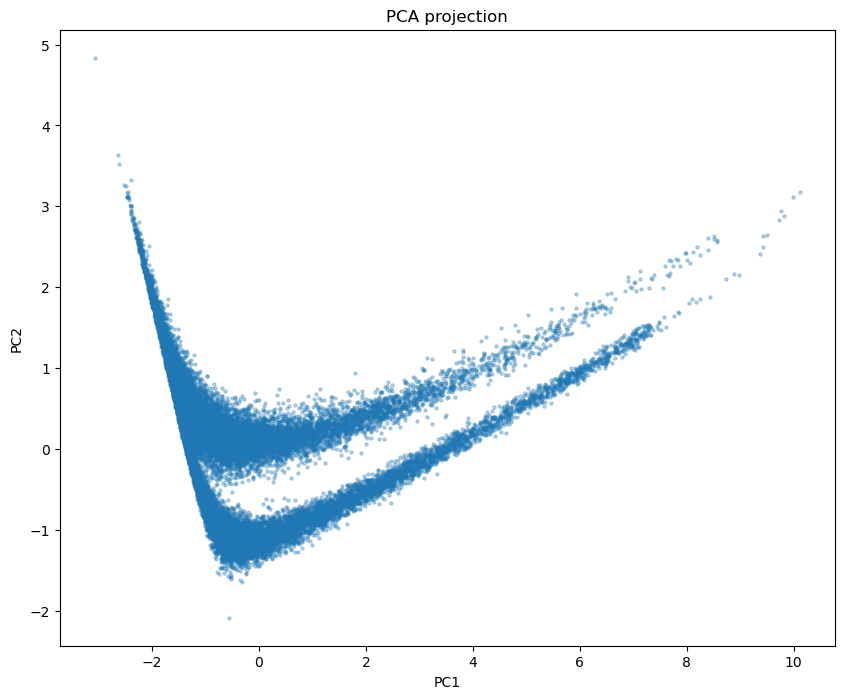

In [27]:
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=5,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection")

plt.show()

In [31]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

clusters_kmeans = kmeans.fit_predict(X_scaled)

clusters_kmeans[:10]

array([0, 2, 2, 0, 2, 0, 0, 0, 2, 2], dtype=int32)

In [32]:
pd.Series(clusters_kmeans).value_counts().sort_index()

0     8806
1     3201
2    11472
Name: count, dtype: int64

In [33]:
pca_df["cluster"] = clusters_kmeans

pca_df.head()

,PC1,PC2,cluster
0,-1.004163,0.030496,0
1,0.296950,-0.995468,2
2,0.718908,-0.791369,2
3,-0.898745,-0.214051,0
4,0.204426,-1.006853,2


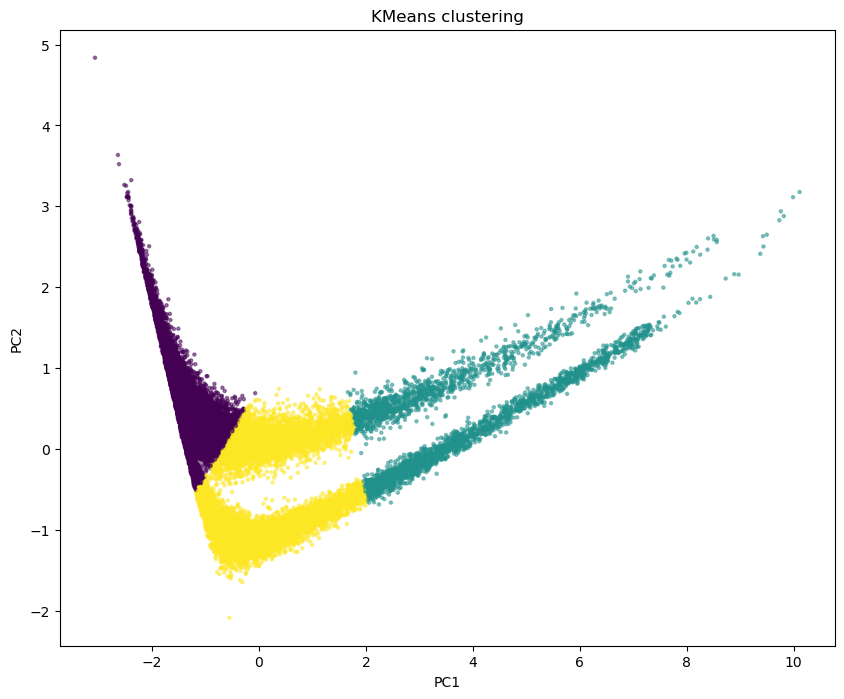

In [34]:
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    s=5,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clustering")

plt.show()

In [36]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42,
    covariance_type="full"
)

clusters_gmm = gmm.fit_predict(X_scaled)

In [37]:
pd.Series(clusters_gmm).value_counts().sort_index()

0    7953
1    6714
2    8812
Name: count, dtype: int64

In [38]:
pca_df["gmm_cluster"] = clusters_gmm

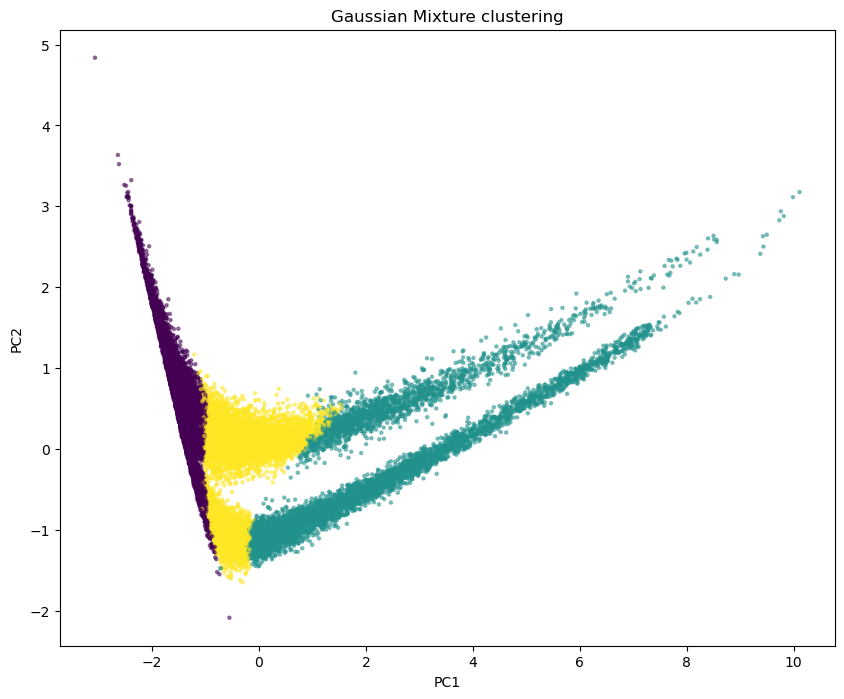

In [39]:
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["gmm_cluster"],
    s=5,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Gaussian Mixture clustering")

plt.show()

In [41]:
sil_kmeans = silhouette_score(
    X_scaled,
    clusters_kmeans
)

sil_gmm = silhouette_score(
    X_scaled,
    clusters_gmm
)

print("KMeans:", sil_kmeans)
print("GMM:", sil_gmm)

KMeans: 0.4403741770173802
GMM: 0.2707558575405986


In [45]:
psd = []

for i in range(len(signals)):
    signal = baseline[i] - signals.iloc[i].values

    start = int(features["min_position"].iloc[i])

    long_area = signal[start:].sum()

    short_area = signal[start:start + 20].sum()

    value = (long_area - short_area) / long_area

    psd.append(value)

psd = np.array(psd)

psd[:5]

array([0.28043338, 0.09696101, 0.09163482, 0.21798005, 0.07284285])

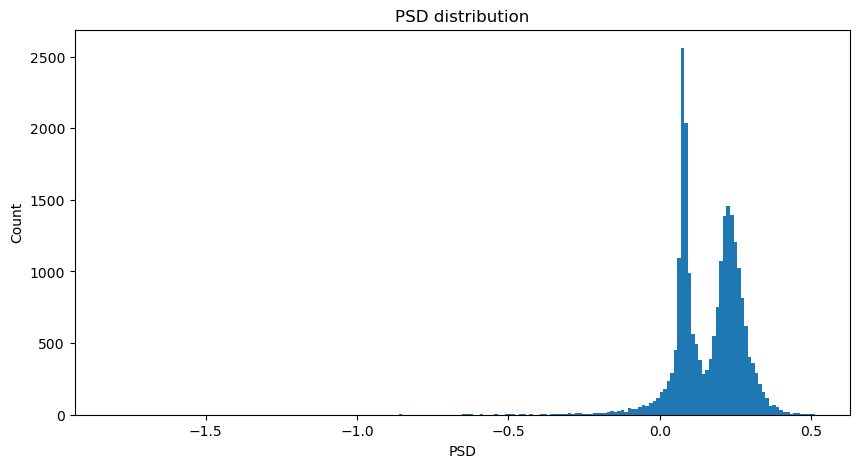

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(psd, bins=200)

plt.xlabel("PSD")
plt.ylabel("Count")
plt.title("PSD distribution")

plt.show()

In [47]:
features["psd"] = psd

features.head()

,baseline,minimum,amplitude,min_position,area,shape_ratio,recovery_area,psd
0,14821.13,14291,530.13,149,4983.28,9.400109,3285.5,0.280433
1,14822.47,12921,1901.47,150,12655.80,6.655798,10118.5,0.096961
2,14821.92,12264,2557.92,151,17264.16,6.749296,13806.0,0.091635
3,14822.76,14258,564.76,149,5015.84,8.881366,3429.0,0.217980
4,14821.43,13028,1793.43,150,12013.03,6.698355,9045.5,0.072843


## Вывод по Feature Engineering

Из исходных временных рядов были сформированы признаки baseline, amplitude, area, shape_ratio, recovery_area и psd.

Полученные признаки позволяют описывать как энергетические характеристики сигнала, так и особенности его формы, что делает их пригодными для последующей кластеризации и разделения различных типов событий.

In [49]:
X_psd = features[
    ["amplitude", "psd"]
]

X_psd.head()

,amplitude,psd
0,530.13,0.280433
1,1901.47,0.096961
2,2557.92,0.091635
3,564.76,0.217980
4,1793.43,0.072843


In [53]:
scaler_psd = StandardScaler()

X_psd_scaled = scaler_psd.fit_transform(X_psd)

X_psd_scaled[:5]

array([[-0.54618523,  1.08401501],
       [ 0.0277772 , -0.57240069],
       [ 0.30252864, -0.62048637],
       [-0.53169114,  0.52017712],
       [-0.017442  , -0.79014304]])

In [54]:
gmm_psd = GaussianMixture(
    n_components=3,
    random_state=42,
    covariance_type="full"
)

clusters_psd = gmm_psd.fit_predict(
    X_psd_scaled
)

pd.Series(clusters_psd).value_counts().sort_index()

0     5491
1    12478
2     5510
Name: count, dtype: int64

In [55]:
features["cluster_psd"] = clusters_psd

features.groupby("cluster_psd")[
    ["amplitude", "psd", "area", "shape_ratio"]
].mean()

,amplitude,psd,area,shape_ratio
cluster_psd,,,,
0,2725.268144,0.220714,22526.910827,8.627593
1,398.129385,0.169597,3567.226973,9.651063
2,4202.193261,0.079309,27063.137463,6.502164


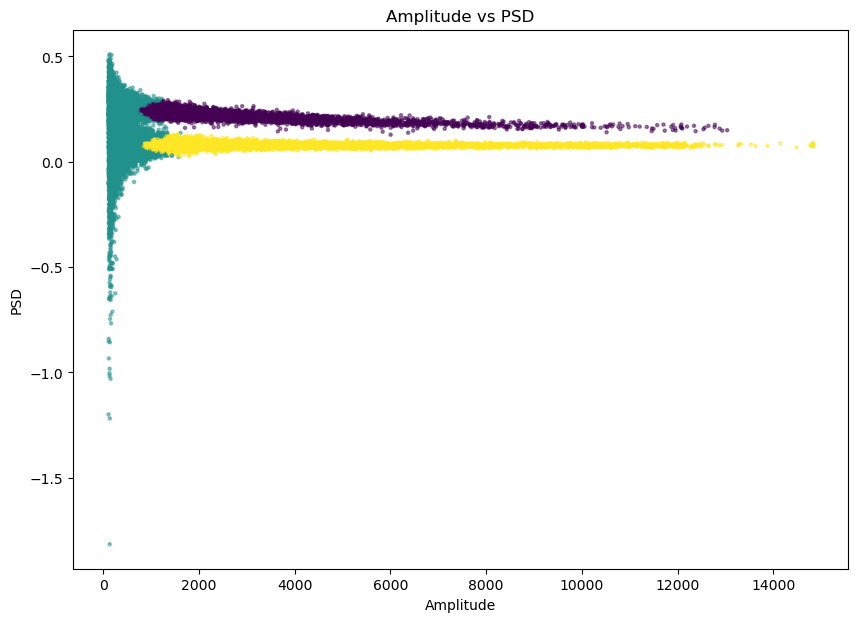

In [56]:
plt.figure(figsize=(10, 7))

plt.scatter(
    features["amplitude"],
    features["psd"],
    c=clusters_psd,
    s=5,
    alpha=0.5
)

plt.xlabel("Amplitude")
plt.ylabel("PSD")
plt.title("Amplitude vs PSD")

plt.show()

In [67]:
X_final = features[
    [
        "amplitude",
        "area",
        "shape_ratio",
        "recovery_area",
        "psd"
    ]
]

X_final.head()

,amplitude,area,shape_ratio,recovery_area,psd
0,530.13,4983.28,9.400109,3285.5,0.280433
1,1901.47,12655.80,6.655798,10118.5,0.096961
2,2557.92,17264.16,6.749296,13806.0,0.091635
3,564.76,5015.84,8.881366,3429.0,0.217980
4,1793.43,12013.03,6.698355,9045.5,0.072843


In [68]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_final)

X_scaled.shape

(23479, 5)

In [69]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

clusters_new = gmm.fit_predict(X_scaled)

pd.Series(clusters_new).value_counts().sort_index()

0    8624
1    5852
2    9003
Name: count, dtype: int64

In [70]:
tmp = X_final.copy()

tmp["cluster"] = clusters_new

tmp.groupby("cluster").mean()

,amplitude,area,shape_ratio,recovery_area,psd
cluster,,,,,
0,517.598308,5142.704006,10.693279,3715.544701,0.254779
1,466.531533,3469.439462,7.901828,1955.556135,0.061513
2,3986.724467,28065.219800,7.238328,24734.865267,0.134174


In [71]:
sil = silhouette_score(X_scaled, clusters_new)

print(sil)

0.33509912040964507


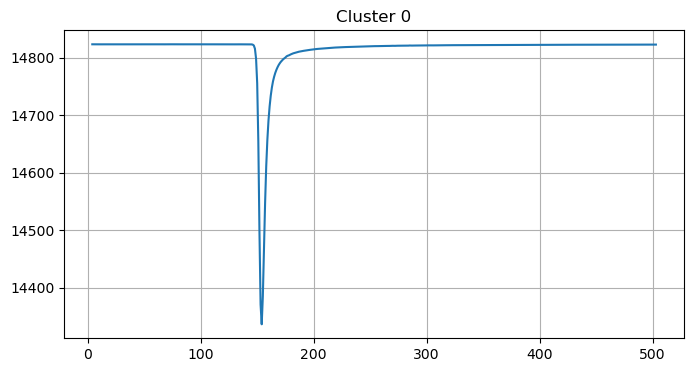

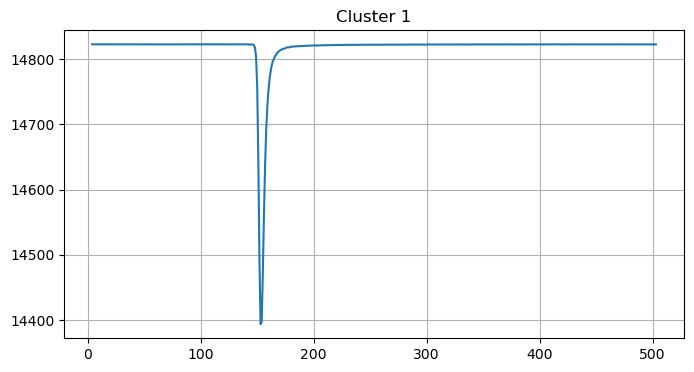

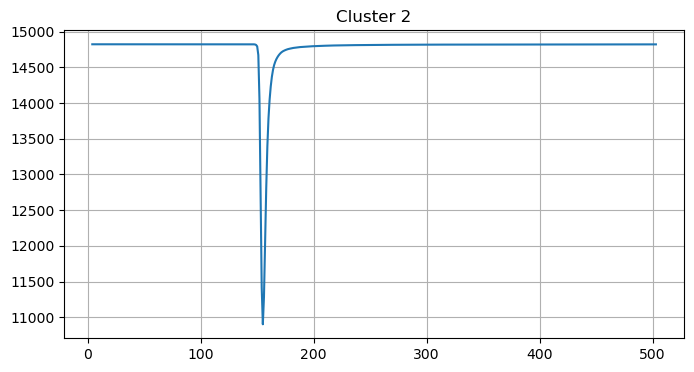

In [72]:
for c in range(3):

    idx = np.where(clusters_new == c)[0]

    mean_signal = signals.iloc[idx].mean(axis=0)

    plt.figure(figsize=(8,4))
    plt.plot(mean_signal)
    plt.title(f"Cluster {c}")
    plt.grid()
    plt.show()

In [73]:
X_final = features[
    ['amplitude',
     'shape_ratio',
     'psd']
]

In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

clusters = gmm.fit_predict(X_scaled)

In [75]:
pd.Series(clusters).value_counts().sort_index()

0     7994
1     5091
2    10394
Name: count, dtype: int64

## Выводы по моделям

Были протестированы алгоритмы KMeans и Gaussian Mixture Model.
Для оценки качества использовался коэффициент Silhouette Score.
Наилучшие результаты показала модель Gaussian Mixture Model, поэтому она была выбрана в качестве итоговой.

In [76]:
submission = pd.DataFrame({
    'index': np.arange(len(clusters)),
    'cluster': clusters
})

submission.head()

,index,cluster
0,0,0
1,1,2
2,2,2
3,3,0
4,4,2


In [79]:
submission.to_csv(
    'submission_gmm.csv',
    index=False
)

In [78]:
pd.read_csv('submission_gmm.csv').head()

,index,cluster
0,0,0
1,1,2
2,2,2
3,3,0
4,4,2


# Общие выводы

В работе выполнена кластеризация сигналов сцинтилляционного детектора на три группы.
Проведен анализ данных, извлечены информативные признаки и выполнено сравнение нескольких алгоритмов кластеризации.
Лучший результат показала модель Gaussian Mixture Model.
Полученные кластеры различаются по амплитудным и временным характеристикам сигналов и могут быть интерпретированы как различные типы событий, регистрируемых детектором.

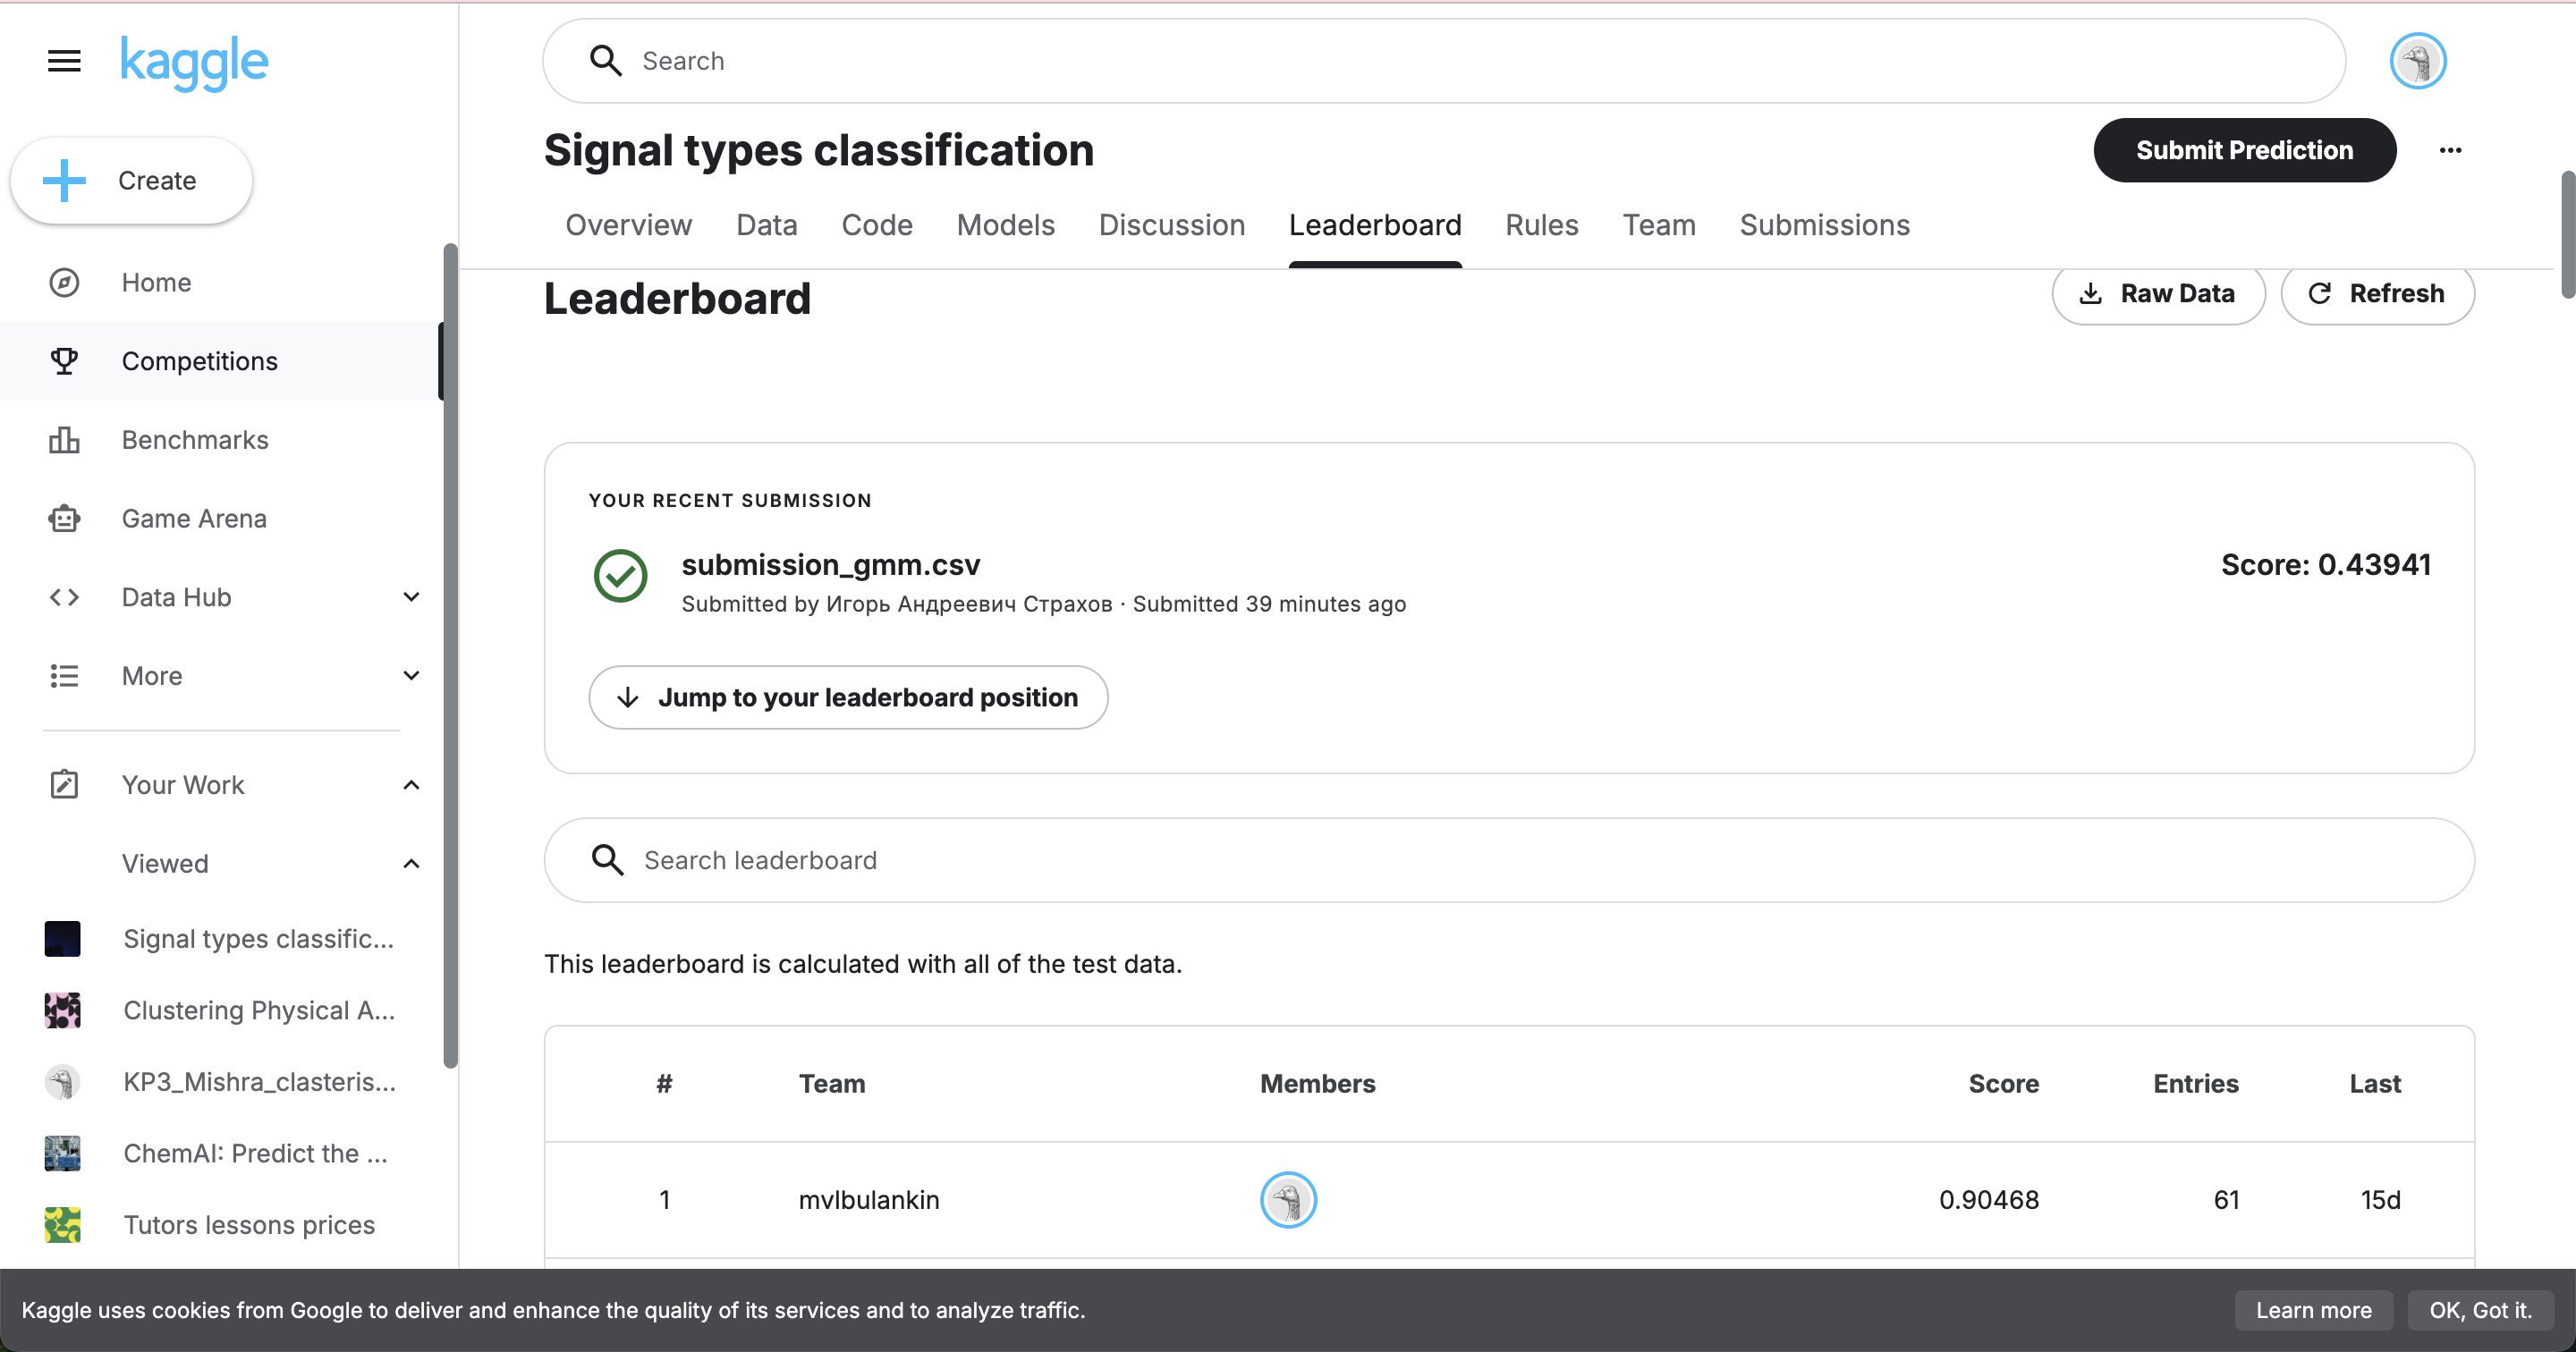